# Lab 6.02 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 2: Flemish agricultural and horticultural businesses

1. Use the dataset agriculture flanders.csv. The file contains data about agricultural and horticultural businesses in Flanders

    Source: Departement Landbouw en Visserij op basis van StatBel

In [2]:
farms = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/agriculture%20flanders.csv', delimiter = ";", decimal=',')
# Show the first few records of the Data Frame
farms.head()

,year,number_of_farms,average_area_per_farm_(ha)
0,1980,75706,8.38
1,1981,73292,8.58
2,1982,71255,8.79
3,1983,69807,8.94
4,1984,68083,9.15


2. What are the datatypes for each of the columns.

In [4]:
farms.dtypes

,0
year,int64
number_of_farms,int64
average_area_per_farm_(ha),float64


3. Draw a scatter plot of the number of farms versus the year.


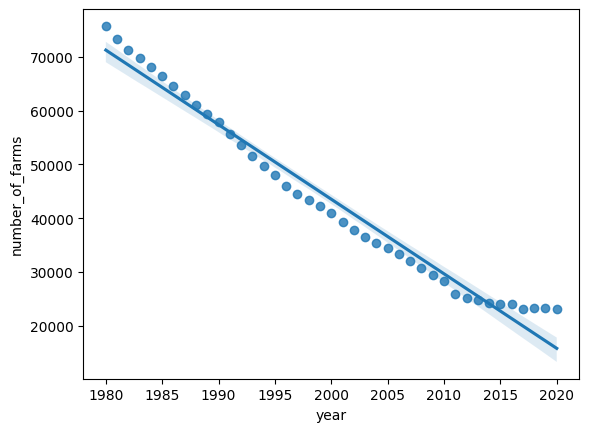

In [5]:
sns.regplot(data=farms, x=farms.year, y=farms.number_of_farms);

4. Is there a positive / negative relationship between year and number_of_farms?

    $R = -0.9861066349492859$

In [6]:
cor = np.corrcoef(x=farms.year, y=farms.number_of_farms)[0, 1]
print(f'Correlation coefficient R: {cor}')

Correlation coefficient R: -0.9861066349492859, R^2: 0.9724062954910041


In [ ]:
R < 0 => there is a negative relationship between year and number_of_farms
# Er is een dalend verband

6. Is there a strong relationship between year and 'number_of_farms'?

    $R^2 = 0.9724062954910041$

In [7]:
cor = np.corrcoef(x=farms.year, y=farms.number_of_farms)[0, 1]
print(f'R^2: {cor**2}')

R^2: 0.9724062954910041


In [ ]:
R ~ 0.97 => there is a strong relationship between year and number_of_farms
# Er is een extreem sterk verband tussen jaar en landbouwbedrijven
# 97% van de variatie van de afh. veranderlijke kan verklaard worden door de onafh veranderlijke

7. Draw a scatter plot of the 'average_area_per_farm_(ha)' versus the year.

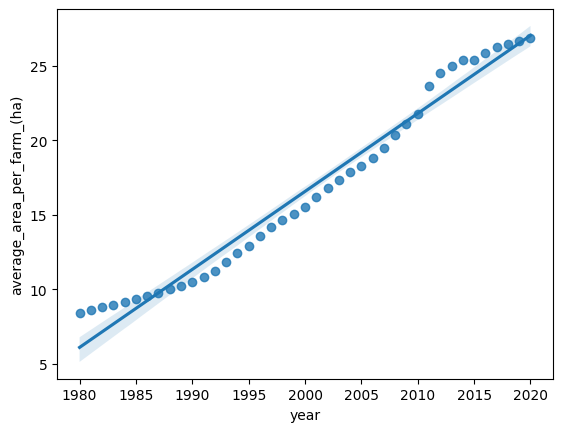

In [10]:
sns.regplot(data=farms, x=farms.year, y=farms['average_area_per_farm_(ha)']);

8. What will be the 'average_area_per_farm_(ha)' in 2035?

Average area in 2035 = 34.91987804878045

In [19]:
b1, b0 = np.polyfit(x=farms.year, y=farms['average_area_per_farm_(ha)'], deg=1)
print(f'y = {b0} + {b1}x')

y = -1031.8951916376452 + 0.5242334494773592x


In [21]:
-1031.8951916376452 + (0.5242334494773592 * 2035)

34.919878048780674

In [18]:
predicted_area_2035 = b0 + (b1 * 2035)
print(f"Average area in 2035 = {predicted_area_2035}")

Average area in 2035 = 34.919878048780674


9. Calculate the total agricultural area for each year.   
Calculate for each year the change of the total area relative to 1980.  
Make a plot.

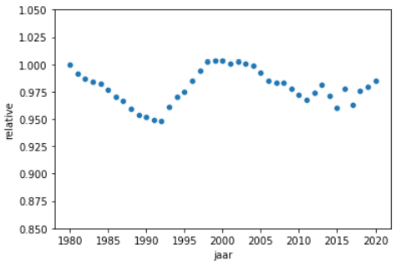


In [22]:
farms['total_agricultural_area'] = farms['number_of_farms']*farms['average_area_per_farm_(ha)']
farms.head()

,year,number_of_farms,average_area_per_farm_(ha),total_agricultural_area
0,1980,75706,8.38,634416.28
1,1981,73292,8.58,628845.36
2,1982,71255,8.79,626331.45
3,1983,69807,8.94,624074.58
4,1984,68083,9.15,622959.45


In [25]:
total_agricultural_area_1980 = farms[farms.year == 1980]["total_agricultural_area"]
#numpie waarde voor berekening
total_agricultural_area_1980 = farms.iloc[0,3]

In [28]:
#relatieve verandering (y2 - y1) / y1

farms['rel_to_1980'] = (farms['total_agricultural_area'] - total_agricultural_area_1980) / total_agricultural_area_1980
farms.head()

,year,number_of_farms,average_area_per_farm_(ha),total_agricultural_area,rel_to_1980
0,1980,75706,8.38,634416.28,0.000000
1,1981,73292,8.58,628845.36,-0.008781
2,1982,71255,8.79,626331.45,-0.012744
3,1983,69807,8.94,624074.58,-0.016301
4,1984,68083,9.15,622959.45,-0.018059


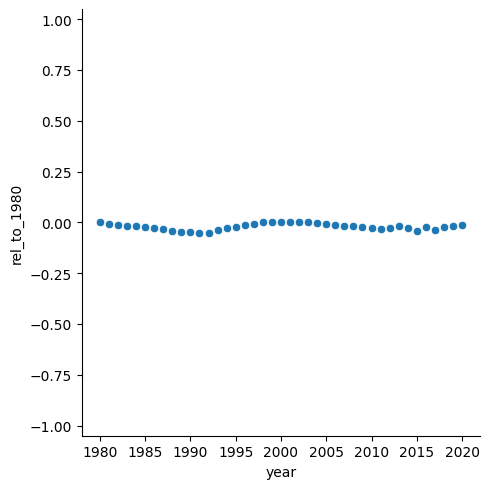

In [35]:
p = sns.relplot(x=farms.year, y=farms.rel_to_1980)
p.set(ylim=(-1.05,1.05))